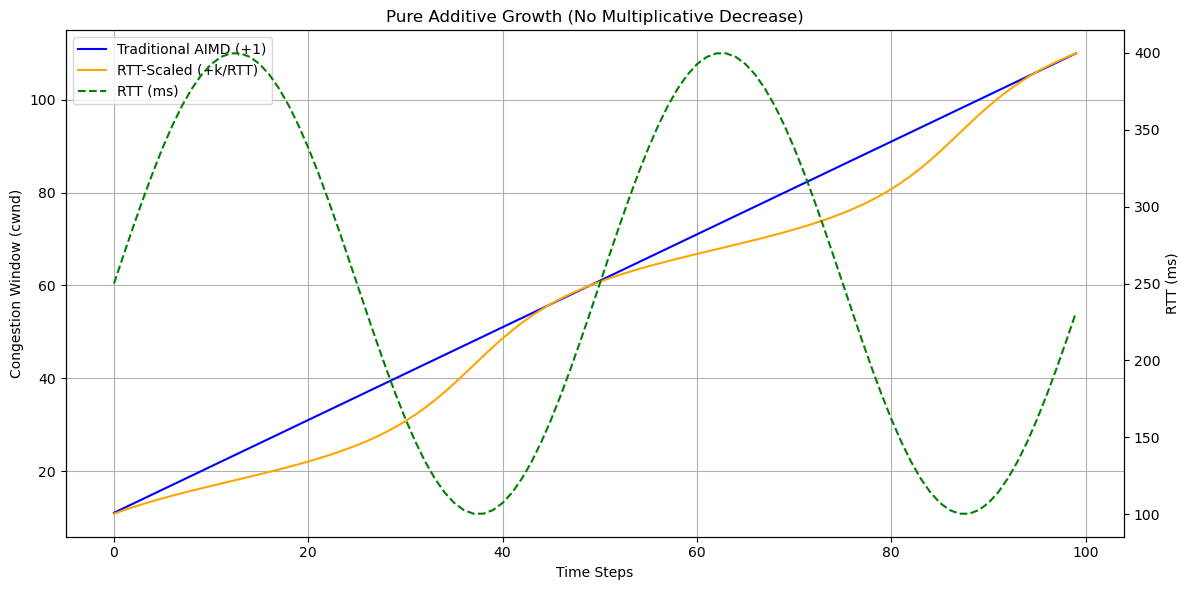

In [29]:
import matplotlib.pyplot as plt
import math


# Simulation Parameters

iterations = 100
RTT_min = 100
RTT_max = 400
k = 200


# Initialize Variables

cwnd_typical = 10
cwnd_rtt_scaled = 10

cwnd_typical_history = []
cwnd_rtt_history = []
RTT_history = []


# Variable RTT (Satellite Orbit)

T_orbit = 50

for t in range(iterations):
    RTT_current = RTT_min + (RTT_max - RTT_min)/2 * (1 + math.sin(2*math.pi*t/T_orbit))
    RTT_history.append(RTT_current)

    # Traditional additive increase
    cwnd_typical += 1

    # RTT-scaled additive increase
    cwnd_rtt_scaled += k / RTT_current

    cwnd_typical_history.append(cwnd_typical)
    cwnd_rtt_history.append(cwnd_rtt_scaled)


# Plot Results
fig, ax1 = plt.subplots(figsize=(12,6))

# cwnd curves
ax1.plot(cwnd_typical_history, label="Traditional AIMD (+1)", color="blue")
ax1.plot(cwnd_rtt_history, label="RTT-Scaled (+k/RTT)", color="orange")

ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Congestion Window (cwnd)")
ax1.set_title("Pure Additive Growth (No Multiplicative Decrease)")
ax1.grid(True)

# RTT on secondary axis
ax2 = ax1.twinx()
ax2.plot(RTT_history, label="RTT (ms)", color="green", linestyle="--")
ax2.set_ylabel("RTT (ms)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

Experimentation on multiplicative decrease

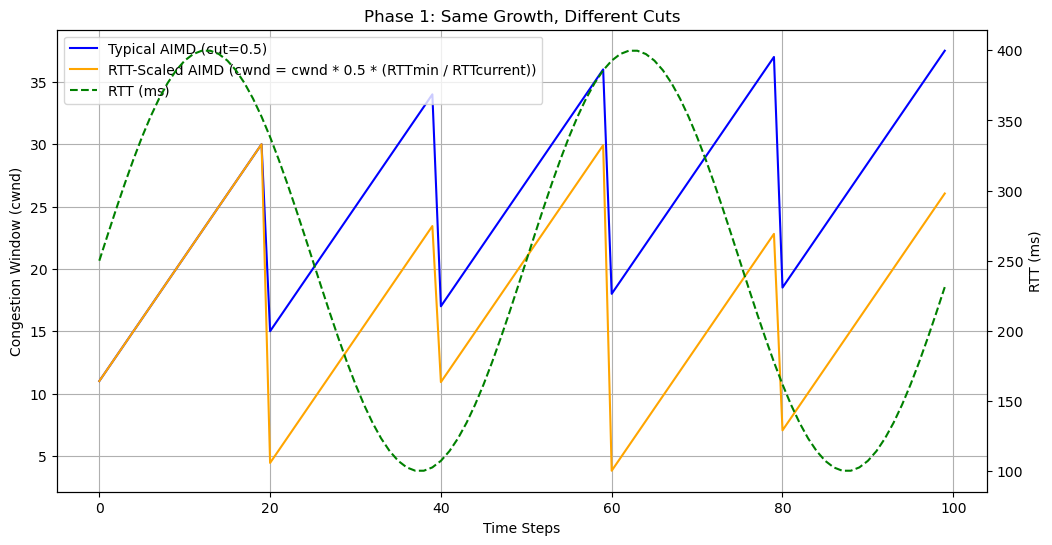

In [16]:
import matplotlib.pyplot as plt
import math

# Simulation parameters
iterations = 100
congestion_events = [20, 40, 60, 80]  # fixed congestion
RTT_min = 100
RTT_max = 400
k = 100  # additive increase scaling for RTT

# Initialize congestion windows
cwnd_typical = 10
cwnd_rtt = 10
cwnd_typical_history = []
cwnd_rtt_history = []
RTT_history = []

# Sinusoidal RTT to mimic satellite orbit, RTT will slowly increase / decrease depending on the orbit.
T_orbit = 50
for t in range(iterations):
    RTT_current = RTT_min + (RTT_max - RTT_min)/2 * (1 + math.sin(2*math.pi*t/T_orbit))
    RTT_history.append(RTT_current)

    # Phase 1: Same growth, different cuts
    if t in congestion_events:
        cwnd_typical *= 0.5
        cwnd_rtt *= 0.5 * (RTT_min / RTT_current)
    else:
        # Same additive increase
        cwnd_typical += 1
        cwnd_rtt += 1
    cwnd_typical_history.append(cwnd_typical)
    cwnd_rtt_history.append(cwnd_rtt)

plt.figure(figsize=(12,6))

# Plot cwnd curves
plt.plot(cwnd_typical_history, label="Typical AIMD (cut=0.5)", color="blue")
plt.plot(cwnd_rtt_history, 
         label="RTT-Scaled AIMD (cwnd = cwnd * 0.5 * (RTTmin / RTTcurrent))",
         color="orange")

plt.xlabel("Time Steps")
plt.ylabel("Congestion Window (cwnd)")
plt.title("Phase 1: Same Growth, Different Cuts")
plt.grid(True)

# ---- Add RTT line on secondary axis ----
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(RTT_history, label="RTT (ms)", color="green", linestyle="--")
ax2.set_ylabel("RTT (ms)")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()



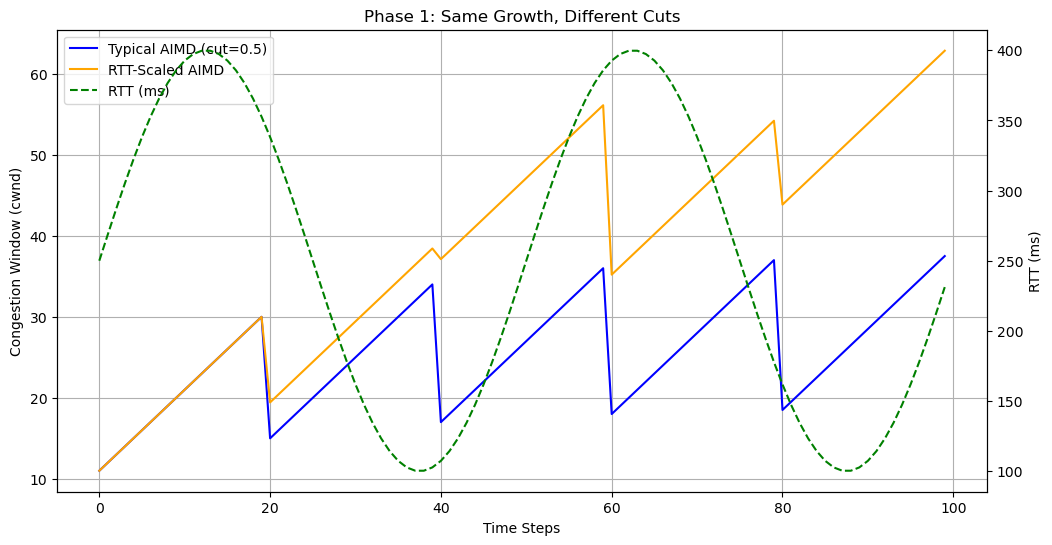

In [17]:
import matplotlib.pyplot as plt
import math

# Simulation parameters
iterations = 100
congestion_events = [20, 40, 60, 80]  # fixed congestion times
RTT_min = 100
RTT_max = 400
k = 100  # additive increase scaling for RTT
base_cut = 0.5  # typical AIMD multiplicative factor

# Initialize congestion windows
cwnd_typical = 10
cwnd_rtt = 10
cwnd_typical_history = []
cwnd_rtt_history = []
RTT_history = []

# Sinusoidal RTT to mimic satellite orbit
T_orbit = 50
for t in range(iterations):
    RTT_current = RTT_min + (RTT_max - RTT_min)/2 * (1 + math.sin(2*math.pi*t/T_orbit))
    RTT_history.append(RTT_current)

    if t in congestion_events:
        # Typical AIMD cut
        cwnd_typical *= base_cut

        # RTT-scaled cut with safe scaling
        md_factor = base_cut + base_cut * (RTT_min / RTT_current)
        md_factor = max(md_factor, 0.5)  # cap at 0.5, typical multiplier of AIMD.
        cwnd_rtt *= md_factor
    else:
        # Same additive increase for fair comparison
        cwnd_typical += 1
        cwnd_rtt += 1

    cwnd_typical_history.append(cwnd_typical)
    cwnd_rtt_history.append(cwnd_rtt)

plt.figure(figsize=(12,6))

# Plot cwnd curves
ax1 = plt.gca()
ax1.plot(cwnd_typical_history, label="Typical AIMD (cut=0.5)", color="blue")
ax1.plot(cwnd_rtt_history, 
         label="RTT-Scaled AIMD", 
         color="orange")

ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Congestion Window (cwnd)")
ax1.set_title("Phase 1: Same Growth, Different Cuts")
ax1.grid(True)

# Add RTT line on secondary axis
ax2 = ax1.twinx()
ax2.plot(RTT_history, 
         label="RTT (ms)", 
         color="green", 
         linestyle="--")
ax2.set_ylabel("RTT (ms)")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()


Final AIMD

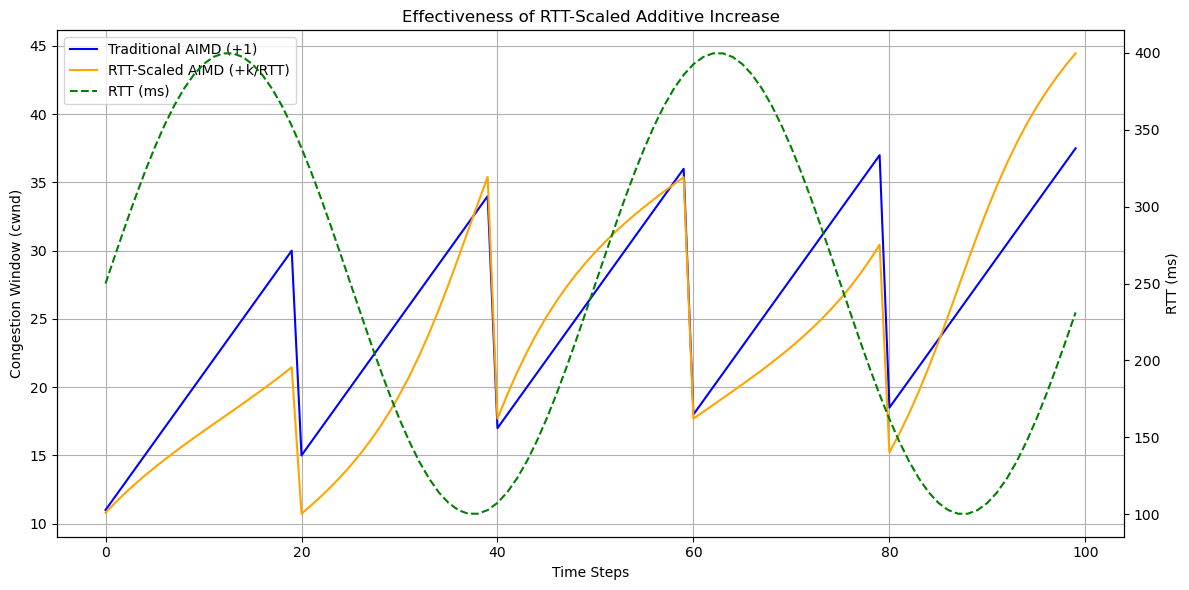

In [24]:
import matplotlib.pyplot as plt
import math

# Simulation Parameters
iterations = 100
congestion_events = [20, 40, 60, 80]
RTT_min = 100
RTT_max = 400
k = 200
base_cut = 0.5


# Initialize Variables
cwnd_typical = 10
cwnd_rtt_scaled = 10

cwnd_typical_history = []
cwnd_rtt_history = []
RTT_history = []


# Generate Variable RTT (Satellite Orbit)
T_orbit = 50  # orbital period

for t in range(iterations):
    # Sinusoidal RTT variation
    RTT_current = RTT_min + (RTT_max - RTT_min)/2 * (1 + math.sin(2*math.pi*t/T_orbit))
    RTT_history.append(RTT_current)

    # Traditional AIMD 
    if t in congestion_events:
        cwnd_typical *= base_cut
    else:
        cwnd_typical += 1

    # RTT-Scaled AIMD
    if t in congestion_events:
        cwnd_rtt_scaled *= base_cut
    else:
        cwnd_rtt_scaled += k / RTT_current

    cwnd_typical_history.append(cwnd_typical)
    cwnd_rtt_history.append(cwnd_rtt_scaled)

# Plot Results
fig, ax1 = plt.subplots(figsize=(12,6))

# Congestion Window Curves
ax1.plot(cwnd_typical_history, 
         label="Traditional AIMD (+1)", 
         color="blue")

ax1.plot(cwnd_rtt_history, 
         label="RTT-Scaled AIMD (+k/RTT)", 
         color="orange")

ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Congestion Window (cwnd)")
ax1.set_title("Effectiveness of RTT-Scaled Additive Increase")
ax1.grid(True)

# Plot RTT on Secondary Axis
ax2 = ax1.twinx()
ax2.plot(RTT_history, 
         label="RTT (ms)", 
         color="green", 
         linestyle="--")

ax2.set_ylabel("RTT (ms)")


# Combine Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()